In [1]:
import numpy as np
import pandas as pd
import torch
import os
import matplotlib.pyplot as plt

d:\Program Files\anaconda3\envs\torch126\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
import sys

from flare_preprocessing import *
from utilities import *


In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
opr = opr_data_preprocessing("D:/2024_S1/ML_SEP_2402/swpc_ftp/v2_ftp_flares_1997_2024.csv")
sci = sci_data_preprocessing("D:/2024_S1/ML_SEP_2402/Sci_matched_with_assigned_ar_20100101_20240721.csv", opr)

d:\2024_S1\ML_SEP_2402\Final_update\Open_Repo\scripts_model_training\utilities.py:64: RuntimeWarning: divide by zero encountered in log10
  return np.log10(intensity * 10 ** -8)


Shape of the operation data: (25364, 9)
Shape of the science-quality data: (30958, 31)


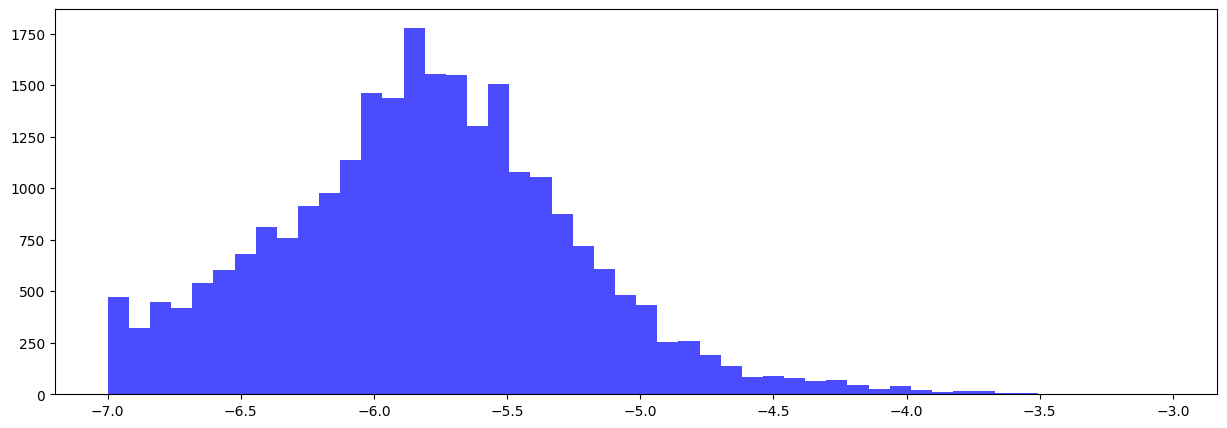

In [6]:
plt.figure(figsize=(15,5))
plt.hist(opr['log_intensity'], bins=50, color='blue', alpha=0.7)
plt.show()

## Definitive SHARP

In [7]:
# read the parquet file
import fastparquet
high_qual_sharp = pd.read_parquet('D:\\0626_temp\\processed_high-qual_near-center-70_no-nas_flares.parquet', engine='fastparquet')

In [11]:
len(high_qual_sharp)

3974765

In [8]:
from New_SampleConstruction import *

In [13]:
high_qual_sharp['HARPNUM'].unique()

<IntegerArray>
[    1,     2,     5,     6,     8,    10,    11,    12,    14,    15,
 ...
 11550, 11556, 11557, 11561, 11562, 11564, 11568, 11569, 11570, 11571]
Length: 6017, dtype: Int64

In [36]:
high_qual_sharp[high_qual_sharp['HARPNUM'] == 1]

,HARPNUM,T_REC,USFLUX,MEANGAM,MEANGBT,MEANGBZ,MEANGBH,MEANJZD,TOTUSJZ,MEANALP,...,T_FRST1,T_LAST1,NOAA_AR,NOAA_NUM,NOAA_ARS,start time,peak time,end time,flare_class,peak_intensity
0,1,2010-05-01 14:00:00+00:00,5.827622e+21,23.887000,73.347000,77.564000,31.354000,-0.151826,4.860817e+12,0.000398,...,2010-05-01 00:00:00+00:00,2010-05-11 16:12:00+00:00,11067,1,11067,NaT,NaT,NaT,None,NaN
1,1,2010-05-01 14:12:00+00:00,5.768150e+21,24.708000,71.970000,76.249000,31.197000,-0.226835,4.908301e+12,0.000081,...,2010-05-01 00:00:00+00:00,2010-05-11 16:12:00+00:00,11067,1,11067,NaT,NaT,NaT,None,NaN
2,1,2010-05-01 14:24:00+00:00,5.865157e+21,25.657000,74.254000,82.154000,32.748000,-0.260023,5.577384e+12,-0.009573,...,2010-05-01 00:00:00+00:00,2010-05-11 16:12:00+00:00,11067,1,11067,NaT,NaT,NaT,None,NaN
3,1,2010-05-01 14:36:00+00:00,5.854875e+21,25.242000,74.539000,81.896000,33.026000,-0.199640,5.290721e+12,-0.013852,...,2010-05-01 00:00:00+00:00,2010-05-11 16:12:00+00:00,11067,1,11067,NaT,NaT,NaT,None,NaN
4,1,2010-05-01 14:48:00+00:00,5.854465e+21,25.876000,75.671000,85.297000,33.556000,-0.403703,5.911234e+12,-0.012455,...,2010-05-01 00:00:00+00:00,2010-05-11 16:12:00+00:00,11067,1,11067,NaT,NaT,NaT,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1207,1,2010-05-11 15:24:00+00:00,2.522491e+21,19.498467,68.526333,68.791133,21.268133,-0.187829,1.926083e+12,-0.007622,...,NaT,NaT,<NA>,<NA>,None,NaT,NaT,NaT,None,NaN
1208,1,2010-05-11 15:36:00+00:00,2.516466e+21,19.467100,68.327500,68.593100,21.268600,-0.186016,1.914007e+12,-0.007523,...,NaT,NaT,<NA>,<NA>,None,NaT,NaT,NaT,None,NaN
1209,1,2010-05-11 15:48:00+00:00,2.510441e+21,19.435733,68.128667,68.395067,21.269067,-0.184204,1.901931e+12,-0.007425,...,NaT,NaT,<NA>,<NA>,None,NaT,NaT,NaT,None,NaN
1210,1,2010-05-11 16:00:00+00:00,2.504415e+21,19.404367,67.929833,68.197033,21.269533,-0.182391,1.889856e+12,-0.007327,...,NaT,NaT,<NA>,<NA>,None,NaT,NaT,NaT,None,NaN


In [9]:
nowcasting_obj_24 = New_SampleConstruction()
nowcasting_obj_24.samples_from_harp(opr, high_qual_sharp, lead_window=0, forecasting_window=24)

Processing HARPNUM: 1
Processing HARPNUM: 2
Processing HARPNUM: 5
Processing HARPNUM: 6
Processing HARPNUM: 8
Processing HARPNUM: 10
Processing HARPNUM: 11
Processing HARPNUM: 12
Processing HARPNUM: 14
Processing HARPNUM: 15
Processing HARPNUM: 16
Processing HARPNUM: 17
Processing HARPNUM: 19
Processing HARPNUM: 20
Processing HARPNUM: 23
Processing HARPNUM: 24
Processing HARPNUM: 25
Processing HARPNUM: 26
Processing HARPNUM: 29
Processing HARPNUM: 32
Processing HARPNUM: 35
Processing HARPNUM: 36
Processing HARPNUM: 37
Processing HARPNUM: 38
Processing HARPNUM: 39
Processing HARPNUM: 40
Processing HARPNUM: 41
Processing HARPNUM: 43
Processing HARPNUM: 44
Processing HARPNUM: 45
Processing HARPNUM: 46
Processing HARPNUM: 47
Processing HARPNUM: 49
Processing HARPNUM: 50
Processing HARPNUM: 51
Processing HARPNUM: 53
Processing HARPNUM: 54
Processing HARPNUM: 57
Processing HARPNUM: 58
Processing HARPNUM: 59
Processing HARPNUM: 62
Processing HARPNUM: 66
Processing HARPNUM: 67
Processing HARPN

d:\2024_S1\ML_SEP_2402\Final_update\Open_Repo\scripts_model_training\New_SampleConstruction.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oneharp['T_REC'] = pd.to_datetime(oneharp['T_REC'])


Processing HARPNUM: 10876
Processing HARPNUM: 10879
Processing HARPNUM: 10880
Processing HARPNUM: 10882
Processing HARPNUM: 10884
Processing HARPNUM: 10885
Processing HARPNUM: 10889
Processing HARPNUM: 10894
Processing HARPNUM: 10895
Processing HARPNUM: 10897
Processing HARPNUM: 10899
Processing HARPNUM: 10900
Processing HARPNUM: 10902
Processing HARPNUM: 10903
Processing HARPNUM: 10907
Processing HARPNUM: 10911
Processing HARPNUM: 10913
Processing HARPNUM: 10915
Processing HARPNUM: 10921
Processing HARPNUM: 10922
Processing HARPNUM: 10923
Processing HARPNUM: 10924
Processing HARPNUM: 10927
Processing HARPNUM: 10928
Processing HARPNUM: 10930
Processing HARPNUM: 10931
Processing HARPNUM: 10933
Processing HARPNUM: 10938
Processing HARPNUM: 10940
Processing HARPNUM: 10941
Processing HARPNUM: 10942
Processing HARPNUM: 10943
Processing HARPNUM: 10944
Processing HARPNUM: 10945
Processing HARPNUM: 10948
Processing HARPNUM: 10949
Processing HARPNUM: 10950
Processing HARPNUM: 10951
Processing H

In [20]:
nowcasting_obj_12 = New_SampleConstruction()
nowcasting_obj_12.samples_from_harp(opr, high_qual_sharp, lead_window=0, forecasting_window=12)

Processing HARPNUM: 1
Processing HARPNUM: 2
Processing HARPNUM: 5
Processing HARPNUM: 6
Processing HARPNUM: 8
Processing HARPNUM: 10
Processing HARPNUM: 11
Processing HARPNUM: 12
Processing HARPNUM: 14
Processing HARPNUM: 15
Processing HARPNUM: 16
Processing HARPNUM: 17
Processing HARPNUM: 19
Processing HARPNUM: 20
Processing HARPNUM: 23
Processing HARPNUM: 24
Processing HARPNUM: 25
Processing HARPNUM: 26
Processing HARPNUM: 29
Processing HARPNUM: 32
Processing HARPNUM: 35
Processing HARPNUM: 36
Processing HARPNUM: 37
Processing HARPNUM: 38
Processing HARPNUM: 39
Processing HARPNUM: 40
Processing HARPNUM: 41
Processing HARPNUM: 43
Processing HARPNUM: 44
Processing HARPNUM: 45
Processing HARPNUM: 46
Processing HARPNUM: 47
Processing HARPNUM: 49
Processing HARPNUM: 50
Processing HARPNUM: 51
Processing HARPNUM: 53
Processing HARPNUM: 54
Processing HARPNUM: 57
Processing HARPNUM: 58
Processing HARPNUM: 59
Processing HARPNUM: 62
Processing HARPNUM: 66
Processing HARPNUM: 67
Processing HARPN

d:\2024_S1\ML_SEP_2402\Final_update\Open_Repo\scripts_model_training\New_SampleConstruction.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oneharp['T_REC'] = pd.to_datetime(oneharp['T_REC'])


Processing HARPNUM: 10876
Processing HARPNUM: 10879
Processing HARPNUM: 10880
Processing HARPNUM: 10882
Processing HARPNUM: 10884
Processing HARPNUM: 10885
Processing HARPNUM: 10889
Processing HARPNUM: 10894
Processing HARPNUM: 10895
Processing HARPNUM: 10897
Processing HARPNUM: 10899
Processing HARPNUM: 10900
Processing HARPNUM: 10902
Processing HARPNUM: 10903
Processing HARPNUM: 10907
Processing HARPNUM: 10911
Processing HARPNUM: 10913
Processing HARPNUM: 10915
Processing HARPNUM: 10921
Processing HARPNUM: 10922
Processing HARPNUM: 10923
Processing HARPNUM: 10924
Processing HARPNUM: 10927
Processing HARPNUM: 10928
Processing HARPNUM: 10930
Processing HARPNUM: 10931
Processing HARPNUM: 10933
Processing HARPNUM: 10938
Processing HARPNUM: 10940
Processing HARPNUM: 10941
Processing HARPNUM: 10942
Processing HARPNUM: 10943
Processing HARPNUM: 10944
Processing HARPNUM: 10945
Processing HARPNUM: 10948
Processing HARPNUM: 10949
Processing HARPNUM: 10950
Processing HARPNUM: 10951
Processing H

In [21]:
nowcasting_obj_6 = New_SampleConstruction()
nowcasting_obj_6.samples_from_harp(opr, high_qual_sharp, lead_window=0, forecasting_window=6)

Processing HARPNUM: 1
Processing HARPNUM: 2
Processing HARPNUM: 5
Processing HARPNUM: 6
Processing HARPNUM: 8
Processing HARPNUM: 10
Processing HARPNUM: 11
Processing HARPNUM: 12
Processing HARPNUM: 14
Processing HARPNUM: 15
Processing HARPNUM: 16
Processing HARPNUM: 17
Processing HARPNUM: 19
Processing HARPNUM: 20
Processing HARPNUM: 23
Processing HARPNUM: 24
Processing HARPNUM: 25
Processing HARPNUM: 26
Processing HARPNUM: 29
Processing HARPNUM: 32
Processing HARPNUM: 35
Processing HARPNUM: 36
Processing HARPNUM: 37
Processing HARPNUM: 38
Processing HARPNUM: 39
Processing HARPNUM: 40
Processing HARPNUM: 41
Processing HARPNUM: 43
Processing HARPNUM: 44
Processing HARPNUM: 45
Processing HARPNUM: 46
Processing HARPNUM: 47
Processing HARPNUM: 49
Processing HARPNUM: 50
Processing HARPNUM: 51
Processing HARPNUM: 53
Processing HARPNUM: 54
Processing HARPNUM: 57
Processing HARPNUM: 58
Processing HARPNUM: 59
Processing HARPNUM: 62
Processing HARPNUM: 66
Processing HARPNUM: 67
Processing HARPN

d:\2024_S1\ML_SEP_2402\Final_update\Open_Repo\scripts_model_training\New_SampleConstruction.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oneharp['T_REC'] = pd.to_datetime(oneharp['T_REC'])


Processing HARPNUM: 10876
Processing HARPNUM: 10879
Processing HARPNUM: 10880
Processing HARPNUM: 10882
Processing HARPNUM: 10884
Processing HARPNUM: 10885
Processing HARPNUM: 10889
Processing HARPNUM: 10894
Processing HARPNUM: 10895
Processing HARPNUM: 10897
Processing HARPNUM: 10899
Processing HARPNUM: 10900
Processing HARPNUM: 10902
Processing HARPNUM: 10903
Processing HARPNUM: 10907
Processing HARPNUM: 10911
Processing HARPNUM: 10913
Processing HARPNUM: 10915
Processing HARPNUM: 10921
Processing HARPNUM: 10922
Processing HARPNUM: 10923
Processing HARPNUM: 10924
Processing HARPNUM: 10927
Processing HARPNUM: 10928
Processing HARPNUM: 10930
Processing HARPNUM: 10931
Processing HARPNUM: 10933
Processing HARPNUM: 10938
Processing HARPNUM: 10940
Processing HARPNUM: 10941
Processing HARPNUM: 10942
Processing HARPNUM: 10943
Processing HARPNUM: 10944
Processing HARPNUM: 10945
Processing HARPNUM: 10948
Processing HARPNUM: 10949
Processing HARPNUM: 10950
Processing HARPNUM: 10951
Processing H

In [16]:
from New_lstm2 import *

Using negative undersampling with 2 negatives per positive.
Each bootstrap will contain approximately 2984 positives and 5968 negatives.
BCE positive-class weight: 2
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.7926546810329824
Epoch 2, avg loss: 0.6291341371294381
Epoch 3, avg loss: 0.5881797489912614
Epoch 4, avg loss: 0.5654218970001608
Epoch 5, avg loss: 0.5562792010065438
Epoch 6, avg loss: 0.5497053390827732
Epoch 7, avg loss: 0.5306694395300271
Epoch 8, avg loss: 0.5162047294602878
Epoch 9, avg loss: 0.5025537605734839
Epoch 10, avg loss: 0.4996190969494806
Epoch 11, avg loss: 0.4770101213800734
Epoch 12, avg loss: 0.489676760158677
Epoch 13, avg loss: 0.4680525505024454
Epoch 14, avg loss: 0.4486954657063968
Epoch 15, avg loss: 0.44315343360969983
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.8056652744611105
Epoch 2, avg loss: 0.6363655138706815
Epoch 3, avg loss: 0.5992750909881316
Epoch 4, avg loss: 0.5763610916725104
Epoch 5, avg loss: 0.5598123617794203
Epoch 6, avg loss:

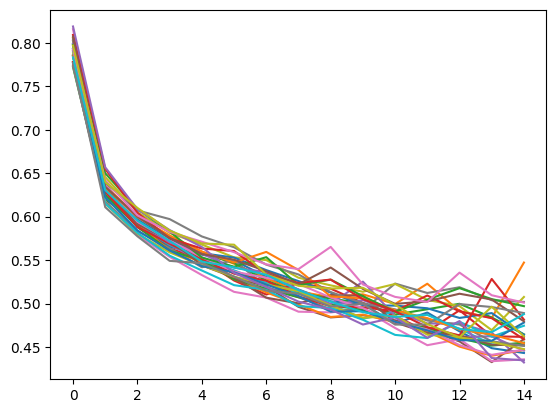

The 95% CI for threshold is 0.28625000000000006 - 0.66375
The 95% CI for TSS is 0.6338786225985021 - 0.703004837884356

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 160.64 seconds
Max CPU memory used: 10047.17 MB
Max GPU memory used: 1291.53 MB


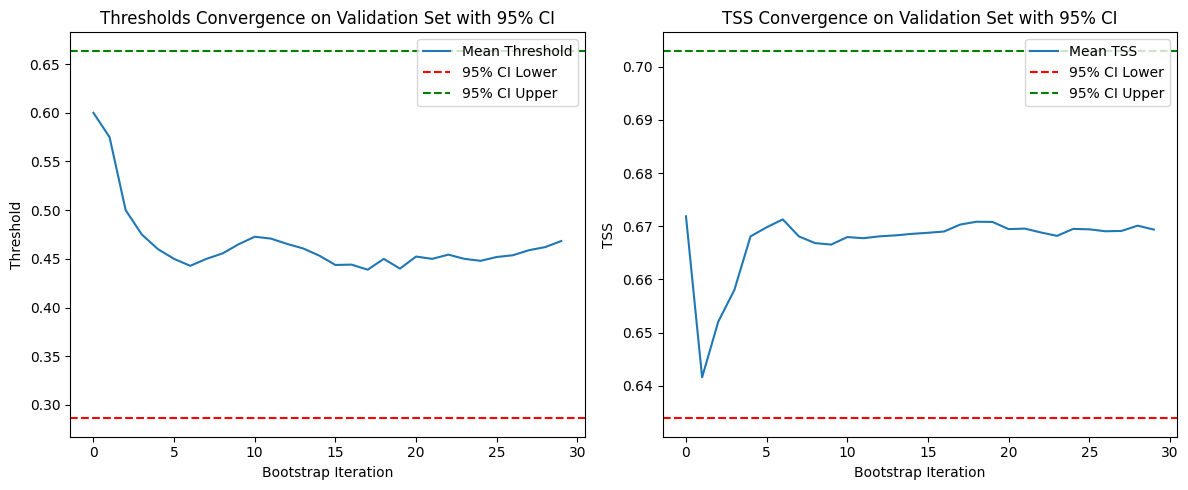

In [17]:
lead0_Mplus2_24_whole = train_lstm(pos_weight=2.0)
lead0_Mplus2_24_whole.train(nowcasting_obj_24.inputs_profile, nowcasting_obj_24.labels, "Mplus2", pd.to_datetime('2010-01-01'), pd.to_datetime('2020-01-01'),n_epoch=15)

In [30]:
working_dir = "D:\\2024_S1\\ML_SEP_2402\\Final_update\\Open_Repo"
save_dir = working_dir + "\\LSTM_models\\WithC_opr_dftSHARP"

In [19]:
for i, model in enumerate(lead0_Mplus2_24_whole.models):
    os.makedirs(save_dir, exist_ok=True)
    model_path = os.path.join(save_dir, f"lead0_Mplus2_24_whole{i}.pth")
    torch.save(model.state_dict(), model_path)

Using negative undersampling with 2 negatives per positive.
Each bootstrap will contain approximately 1854 positives and 3708 negatives.
BCE positive-class weight: 2
Bootstrap iteration 1/30
Epoch 1, avg loss: 0.8521208679953287
Epoch 2, avg loss: 0.7000398122987082
Epoch 3, avg loss: 0.6482248888459317
Epoch 4, avg loss: 0.6180591403051864
Epoch 5, avg loss: 0.6037055960921354
Epoch 6, avg loss: 0.5892500905103462
Epoch 7, avg loss: 0.5730980426766151
Epoch 8, avg loss: 0.5556618612866069
Epoch 9, avg loss: 0.5421923683133236
Epoch 10, avg loss: 0.5334750802017921
Epoch 11, avg loss: 0.5293677726457285
Epoch 12, avg loss: 0.5246136271676352
Epoch 13, avg loss: 0.5112530824749969
Epoch 14, avg loss: 0.5029488524725271
Epoch 15, avg loss: 0.5158447096514147
Bootstrap iteration 2/30
Epoch 1, avg loss: 0.8431651869485545
Epoch 2, avg loss: 0.6862790972687477
Epoch 3, avg loss: 0.6334896697554477
Epoch 4, avg loss: 0.6082896756571393
Epoch 5, avg loss: 0.5993168201557425
Epoch 6, avg loss:

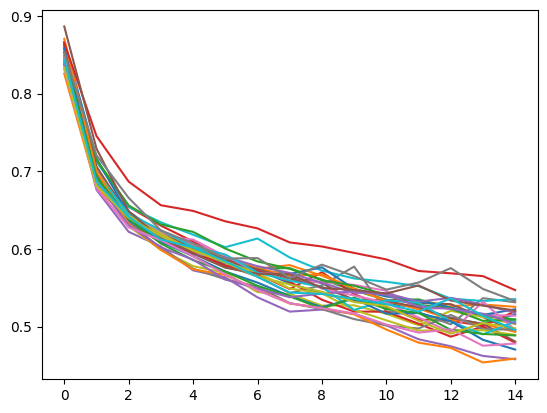

The 95% CI for threshold is 0.28625000000000006 - 0.61375
The 95% CI for TSS is 0.6202039794102289 - 0.6823056653842464

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 1754.14 seconds
Max CPU memory used: 4402.61 MB
Max GPU memory used: 2454.05 MB


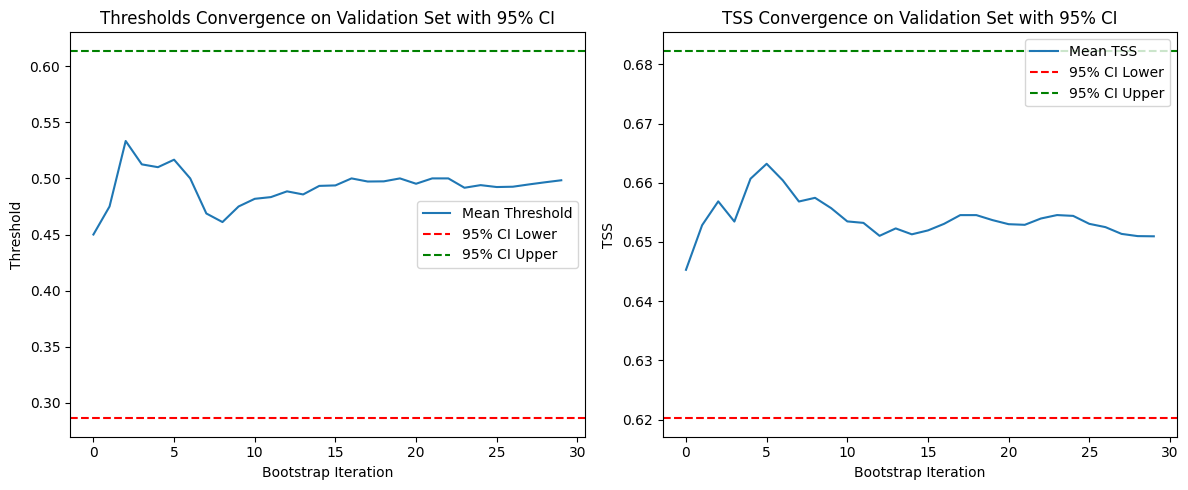

In [22]:
lead0_Mplus2_12_whole = train_lstm(pos_weight=2.0)
lead0_Mplus2_12_whole.train(nowcasting_obj_12.inputs_profile, nowcasting_obj_12.labels, "Mplus2", pd.to_datetime('2010-01-01'), pd.to_datetime('2020-01-01'),n_epoch=15)

In [23]:
for i, model in enumerate(lead0_Mplus2_12_whole.models):
    model_path = os.path.join(save_dir, f"lead0_Mplus2_12_whole{i}.pth")
    torch.save(model.state_dict(), model_path)

Using all training samples: 1083 positives and 10823 negatives.
BCE positive-class weight: 9.9935
Bootstrap iteration 1/30
Epoch 1, avg loss: 1.0834418381414106
Epoch 2, avg loss: 0.9025901709833453
Epoch 3, avg loss: 0.8597695051982839
Epoch 4, avg loss: 0.8480681514227262
Epoch 5, avg loss: 0.8013764260917582
Epoch 6, avg loss: 0.808764636516571
Epoch 7, avg loss: 0.7871421655660035
Epoch 8, avg loss: 0.7744029353382766
Epoch 9, avg loss: 0.7567652377390093
Epoch 10, avg loss: 0.7613267142285582
Epoch 11, avg loss: 0.7524130395663682
Epoch 12, avg loss: 0.7463212590063771
Epoch 13, avg loss: 0.7153562262494076
Epoch 14, avg loss: 0.7001938021952107
Epoch 15, avg loss: 0.6995986004670461
Bootstrap iteration 2/30
Epoch 1, avg loss: 1.0834541641255861
Epoch 2, avg loss: 0.9332310948320615
Epoch 3, avg loss: 0.8838079042973057
Epoch 4, avg loss: 0.8444325391964246
Epoch 5, avg loss: 0.8181974035437389
Epoch 6, avg loss: 0.8107885455572477
Epoch 7, avg loss: 0.7948430392049974
Epoch 8, av

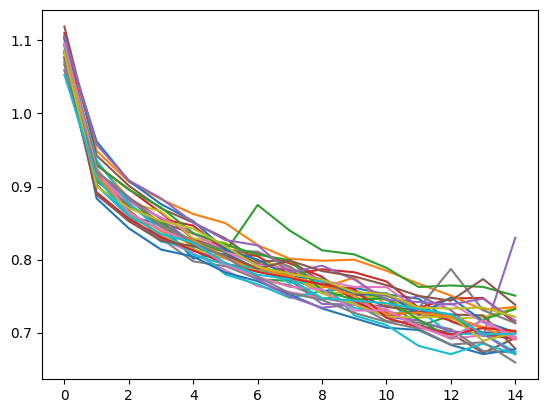

The 95% CI for threshold is 0.2225 - 0.65
The 95% CI for TSS is 0.572609102244389 - 0.6521820448877806

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 3499.00 seconds
Max CPU memory used: 10500.86 MB
Max GPU memory used: 4047.53 MB


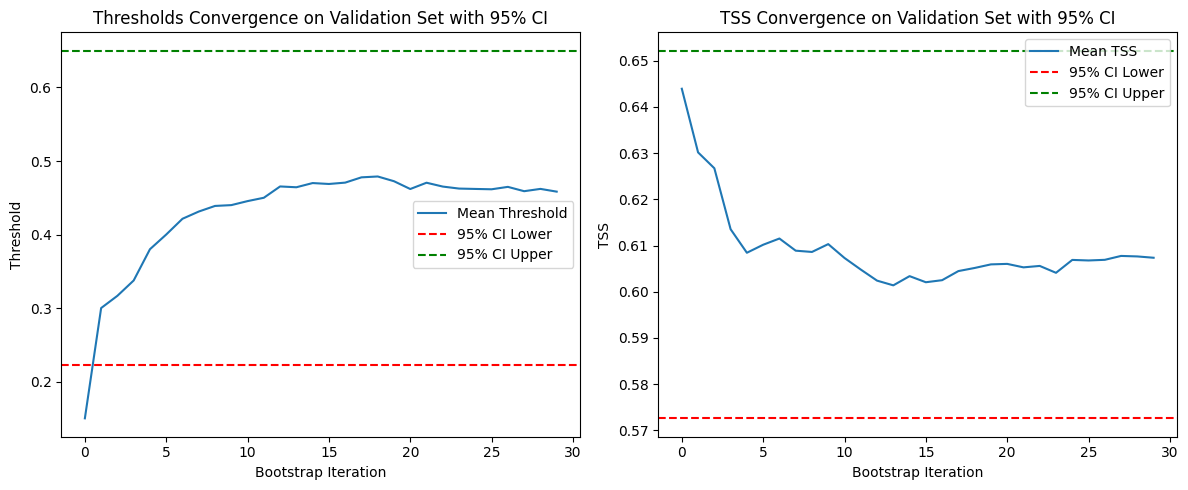

In [38]:
lead0_Mplus2_6_whole = train_lstm()
lead0_Mplus2_6_whole.train(nowcasting_obj_6.inputs_profile, nowcasting_obj_6.labels, "Mplus2", pd.to_datetime('2010-01-01'), pd.to_datetime('2020-01-01'),n_epoch=15)

In [40]:
for i, model in enumerate(lead0_Mplus2_6_whole.models):
    model_path = os.path.join(save_dir, f"lead0_Mplus2_6_whole{i}.pth")
    torch.save(model.state_dict(), model_path)

In [32]:
def GenScripts(
    model_name,
    model_obj,
    sample_obj,
    time1,
    time2,
    model_dir,
    batch_size=2048,
    n_models=30,
    num_workers=0
):
    """
    Evaluate multiple saved LSTM bootstrap models using batched inference.

    Parameters
    ----------
    batch_size : int
        Number of samples evaluated at once. Increase until GPU memory
        utilization is reasonably high without causing out-of-memory errors.
    n_models : int
        Number of bootstrap models to evaluate.
    num_workers : int
        Number of DataLoader workers. On Windows, 0 is often the safest.
    """

    # ---------------------------------------------------------
    # Prepare test samples
    # ---------------------------------------------------------
    te_pos_inputs, te_neg_inputs = get_samples(
        sample_obj.inputs_profile,
        sample_obj.labels,
        "Mplus2",
        time1,
        time2
    )

    print(
        f"Positive: {te_pos_inputs.shape[0]}, "
        f"Negative: {te_neg_inputs.shape[0]}"
    )

    te_inputs, te_targets = combine(
        te_pos_inputs,
        te_neg_inputs
    )

    # Avoid an unnecessary explicit copy unless normalize2 requires it.
    te_inputs = normalize2(
        te_inputs,
        te_inputs
    )

    te_inputs = np.asarray(
        te_inputs,
        dtype=np.float32
    )

    te_targets = np.asarray(
        te_targets,
        dtype=np.int64
    ).reshape(-1)

    # ---------------------------------------------------------
    # DataLoader for batched inference
    # ---------------------------------------------------------
    test_dataset = torch.utils.data.TensorDataset(
        torch.from_numpy(te_inputs)
    )

    use_cuda = (
        isinstance(DEVICE, torch.device)
        and DEVICE.type == "cuda"
    ) or str(DEVICE).startswith("cuda")

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=use_cuda,
        drop_last=False
    )

    # ---------------------------------------------------------
    # Allocate metric arrays
    # ---------------------------------------------------------
    pods = np.empty(n_models, dtype=np.float64)
    fars = np.empty(n_models, dtype=np.float64)
    tsss = np.empty(n_models, dtype=np.float64)
    hsss = np.empty(n_models, dtype=np.float64)
    f1s = np.empty(n_models, dtype=np.float64)

    input_dim = te_inputs.shape[2]

    # Construct the model once and repeatedly load its parameters.
    model = lstm(input_dim).to(DEVICE)
    model.eval()

    # ---------------------------------------------------------
    # Evaluate all bootstrap models
    # ---------------------------------------------------------
    for i in range(n_models):
        threshold = float(model_obj.thresholds[i])

        path = os.path.join(
            model_dir,
            f"{model_name}{i}.pth"
        )

        state_dict = torch.load(
            path,
            map_location=DEVICE,
            weights_only=True
        )

        model.load_state_dict(state_dict)
        model.eval()

        predictions = []

        with torch.inference_mode():
            for (batch_inputs,) in test_loader:
                batch_inputs = batch_inputs.to(
                    DEVICE,
                    dtype=torch.float32,
                    non_blocking=use_cuda
                )

                logits = model(batch_inputs).reshape(-1)

                # Sigmoid is unnecessary for thresholding if the probability
                # threshold is converted to the equivalent logit threshold.
                if 0.0 < threshold < 1.0:
                    logit_threshold = np.log(
                        threshold / (1.0 - threshold)
                    )

                    batch_pred = (
                        logits > logit_threshold
                    ).to(torch.uint8)
                elif threshold <= 0.0:
                    batch_pred = torch.ones_like(
                        logits,
                        dtype=torch.uint8
                    )
                else:
                    batch_pred = torch.zeros_like(
                        logits,
                        dtype=torch.uint8
                    )

                predictions.append(
                    batch_pred.cpu()
                )

        y_pred_i = torch.cat(
            predictions
        ).numpy()

        tsss[i] = TSS(y_pred_i, te_targets)
        pods[i] = POD(y_pred_i, te_targets)
        fars[i] = FAR(y_pred_i, te_targets)
        hsss[i] = HSS(y_pred_i, te_targets)
        f1s[i] = F1(y_pred_i, te_targets)

    # ---------------------------------------------------------
    # Report results
    # ---------------------------------------------------------
    def print_summary(name, values):
        print(
            f"{name}: "
            f"{values.mean():.2f}"
            f"[{values.min():.2f},"
            f"{values.max():.2f}]"
        )

    print_summary("TSS", tsss)
    print_summary("HSS", hsss)
    print_summary("POD", pods)
    print_summary("F1", f1s)
    print_summary("FAR", fars)

    return tsss, hsss, pods, f1s, fars

### lead0, 24

In [28]:
tsss, hsss, pods, f1s, fars = GenScripts("lead0_Mplus2_24_whole", lead0_Mplus2_24_whole, nowcasting_obj_24, pd.to_datetime('2020-01-01'), pd.to_datetime('2022-01-01'), save_dir)

Positive: 138, Negative: 3692
TSS: 0.37[0.19,0.50]
HSS: 0.09[0.05,0.13]
POD: 0.64[0.40,0.78]
F1: 0.15[0.11,0.18]
FAR: 0.27[0.19,0.33]


In [29]:
tsss, hsss, pods, f1s, fars = GenScripts("lead0_Mplus2_24_whole", lead0_Mplus2_24_whole, nowcasting_obj_24, pd.to_datetime('2022-01-01'), pd.to_datetime('2023-01-01'), save_dir)

Positive: 707, Negative: 5065
TSS: 0.36[0.31,0.43]
HSS: 0.23[0.19,0.30]
POD: 0.61[0.49,0.72]
F1: 0.36[0.33,0.41]
FAR: 0.25[0.16,0.35]


In [31]:
tsss, hsss, pods, f1s, fars = GenScripts("lead0_Mplus2_24_whole", lead0_Mplus2_24_whole, nowcasting_obj_24, pd.to_datetime('2023-01-01'), pd.to_datetime('2025-01-01'), save_dir)

Positive: 2823, Negative: 7974
TSS: 0.36[0.29,0.40]
HSS: 0.34[0.31,0.38]
POD: 0.57[0.43,0.65]
F1: 0.52[0.47,0.56]
FAR: 0.21[0.12,0.29]


In [33]:
tsss, hsss, pods, f1s, fars = GenScripts("lead0_Mplus2_24_whole", lead0_Mplus2_24_whole, nowcasting_obj_24, pd.to_datetime('2020-01-01'), pd.to_datetime('2025-01-01'), save_dir)

Positive: 3668, Negative: 16731
TSS: 0.38[0.31,0.41]
HSS: 0.31[0.28,0.35]
POD: 0.60[0.47,0.69]
F1: 0.46[0.43,0.49]
FAR: 0.22[0.14,0.29]


## lead0, 12

In [34]:
tsss, hsss, pods, f1s, fars = GenScripts("lead0_Mplus2_12_whole", lead0_Mplus2_12_whole, nowcasting_obj_12, pd.to_datetime('2020-01-01'), pd.to_datetime('2022-01-01'), save_dir)

Positive: 77, Negative: 2691
TSS: 0.40[0.18,0.57]
HSS: 0.07[0.03,0.10]
POD: 0.70[0.43,0.88]
F1: 0.12[0.08,0.15]
FAR: 0.30[0.23,0.35]


In [35]:
tsss, hsss, pods, f1s, fars = GenScripts("lead0_Mplus2_12_whole", lead0_Mplus2_12_whole, nowcasting_obj_12, pd.to_datetime('2022-01-01'), pd.to_datetime('2023-01-01'), save_dir)

Positive: 428, Negative: 3634
TSS: 0.36[0.31,0.42]
HSS: 0.19[0.16,0.25]
POD: 0.63[0.55,0.70]
F1: 0.32[0.30,0.36]
FAR: 0.27[0.20,0.33]


In [36]:
tsss, hsss, pods, f1s, fars = GenScripts("lead0_Mplus2_12_whole", lead0_Mplus2_12_whole, nowcasting_obj_12, pd.to_datetime('2023-01-01'), pd.to_datetime('2025-01-01'), save_dir)

Positive: 1763, Negative: 5930
TSS: 0.34[0.31,0.39]
HSS: 0.30[0.27,0.36]
POD: 0.58[0.50,0.64]
F1: 0.49[0.47,0.52]
FAR: 0.24[0.16,0.31]


In [37]:
tsss, hsss, pods, f1s, fars = GenScripts("lead0_Mplus2_12_whole", lead0_Mplus2_12_whole, nowcasting_obj_12, pd.to_datetime('2020-01-01'), pd.to_datetime('2025-01-01'), save_dir)

Positive: 2268, Negative: 12255
TSS: 0.38[0.35,0.41]
HSS: 0.27[0.24,0.33]
POD: 0.62[0.54,0.69]
F1: 0.42[0.40,0.45]
FAR: 0.25[0.18,0.32]


## lead0, 6

In [41]:
tsss, hsss, pods, f1s, fars = GenScripts("lead0_Mplus2_6_whole", lead0_Mplus2_6_whole, nowcasting_obj_6, pd.to_datetime('2020-01-01'), pd.to_datetime('2022-01-01'), save_dir)

Positive: 42, Negative: 1862
TSS: 0.32[0.07,0.50]
HSS: 0.04[0.01,0.07]
POD: 0.63[0.24,0.83]
F1: 0.08[0.05,0.11]
FAR: 0.30[0.17,0.36]


In [42]:
tsss, hsss, pods, f1s, fars = GenScripts("lead0_Mplus2_6_whole", lead0_Mplus2_6_whole, nowcasting_obj_6, pd.to_datetime('2022-01-01'), pd.to_datetime('2023-01-01'), save_dir)

Positive: 247, Negative: 2460
TSS: 0.31[0.25,0.35]
HSS: 0.15[0.12,0.22]
POD: 0.58[0.45,0.68]
F1: 0.27[0.24,0.31]
FAR: 0.28[0.15,0.35]


In [43]:
tsss, hsss, pods, f1s, fars = GenScripts("lead0_Mplus2_6_whole", lead0_Mplus2_6_whole, nowcasting_obj_6, pd.to_datetime('2023-01-01'), pd.to_datetime('2025-01-01'), save_dir)

Positive: 1047, Negative: 4092
TSS: 0.30[0.25,0.36]
HSS: 0.25[0.20,0.29]
POD: 0.55[0.40,0.67]
F1: 0.43[0.40,0.47]
FAR: 0.25[0.14,0.33]


In [ ]:
tsss, hsss, pods, f1s, fars = GenScripts("lead0_Mplus2_6_whole", lead0_Mplus2_6_whole, nowcasting_obj_6, pd.to_datetime('2020-01-01'), pd.to_datetime('2025-01-01'), save_dir)

Positive: 1336, Negative: 8414


## NRT  SHARP

In [14]:
from pathlib import Path

def read_all_harp_csvs(root: str | Path, recursive: bool = False) -> pd.DataFrame:
    """
    Read all per-HARP CSVs under `root`, concatenate them in ascending HARP order,
    Assumes files are named like HARP_<harpnum>.csv.
    """

    root = Path(root)
    pattern = "**/HARP_*.csv" if recursive else "HARP_*.csv"

    # List files first, sorted by HARP number
    harp_files = []
    for f in root.glob(pattern):
        try:
            harpnum = int(f.stem.split("_")[1])
            harp_files.append((harpnum, f))
        except Exception:
            continue

    # sort by numeric harp number
    harp_files.sort(key=lambda x: x[0])

    frames = []

    for harpnum, f in harp_files:
        # read with T_REC parsed as datetime
        df = pd.read_csv(f, parse_dates=["T_REC"])
        print(f"Reading HARP {harpnum}")

        # Skip if the HARP lifetime is less than 120 rows (24h / 12min cadence)
        if len(df) < 120:
            print(f"  -> Skipping HARP {harpnum} (too short)")
            continue
        # fill the HARPNUM with the harpnum
        df['HARPNUM'] = harpnum
        frames.append(df)

    if not frames:
        print("No valid HARP CSVs found.")
        return pd.DataFrame()

    # Concatenate in correct order
    full_df = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(frames)} HARPs; total rows = {len(full_df)}")
    
    return full_df

In [2]:
import numpy as np
l = np.array([2, 3, 5, 8, 9, 10])
rss = [np.sum((l - np.mean(l)) ** 2)]
rss

[np.float64(54.833333333333336)]

In [15]:
nrt_sharps = read_all_harp_csvs(r"D:\\Input Data\\Operational Data\\HMI\SHARP_by_HARP")

Reading HARP 476
Reading HARP 487
Reading HARP 493
Reading HARP 495
Reading HARP 497
Reading HARP 498
Reading HARP 499
  -> Skipping HARP 499 (too short)
Reading HARP 500
  -> Skipping HARP 500 (too short)
Reading HARP 501
Reading HARP 502
Reading HARP 503
Reading HARP 504
Reading HARP 505
Reading HARP 506
  -> Skipping HARP 506 (too short)
Reading HARP 508
Reading HARP 509
Reading HARP 510
Reading HARP 511
Reading HARP 512
Reading HARP 513
  -> Skipping HARP 513 (too short)
Reading HARP 514
  -> Skipping HARP 514 (too short)
Reading HARP 515
Reading HARP 516
Reading HARP 518
  -> Skipping HARP 518 (too short)
Reading HARP 520
Reading HARP 521
Reading HARP 523
Reading HARP 524
  -> Skipping HARP 524 (too short)
Reading HARP 526
Reading HARP 527
Reading HARP 529
Reading HARP 532
Reading HARP 533
  -> Skipping HARP 533 (too short)
Reading HARP 534
Reading HARP 537
Reading HARP 547
  -> Skipping HARP 547 (too short)
Reading HARP 550
Reading HARP 552
  -> Skipping HARP 552 (too short)
Read

C:\Users\huke0\AppData\Local\Temp\ipykernel_35496\2427577827.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(f, parse_dates=["T_REC"])


Reading HARP 11246
Reading HARP 11248
Reading HARP 11249
  -> Skipping HARP 11249 (too short)
Reading HARP 11250
Reading HARP 11251
Reading HARP 11252
  -> Skipping HARP 11252 (too short)
Reading HARP 11253
Reading HARP 11255
Reading HARP 11256
  -> Skipping HARP 11256 (too short)
Reading HARP 11258
Reading HARP 11259
  -> Skipping HARP 11259 (too short)
Reading HARP 11260
  -> Skipping HARP 11260 (too short)
Reading HARP 11262
  -> Skipping HARP 11262 (too short)
Reading HARP 11263
  -> Skipping HARP 11263 (too short)
Reading HARP 11264
  -> Skipping HARP 11264 (too short)
Reading HARP 11266
  -> Skipping HARP 11266 (too short)
Reading HARP 11269
  -> Skipping HARP 11269 (too short)
Reading HARP 11330
Reading HARP 11336
  -> Skipping HARP 11336 (too short)
Reading HARP 11338
Reading HARP 11340
Reading HARP 11348
  -> Skipping HARP 11348 (too short)
Reading HARP 11351
  -> Skipping HARP 11351 (too short)
Reading HARP 11363
  -> Skipping HARP 11363 (too short)
Reading HARP 11364
Reading

In [19]:
nrt_sharps.shape

(1680341, 28)

In [18]:
nrt_sharps.isna().sum()

T_REC            0
HARPNUM          0
NOAA_AR     196501
LAT_MIN     196501
LON_MIN     196501
LAT_MAX     196501
LON_MAX     196501
USFLUX           0
MEANGAM      17491
MEANGBT      18158
MEANGBZ      17491
MEANGBH      17491
MEANJZD      17491
TOTUSJZ          0
MEANALP      18158
MEANJZH      18158
TOTUSJH          0
ABSNJZH          0
SAVNCPP          0
MEANPOT      17491
TOTPOT           0
MEANSHR      17616
SHRGT45      17491
SIZE             0
SIZE_ACR         0
NACR             0
NPIX             0
QUALITY     196501
dtype: int64

In [79]:
# delete rows with key columns any NaN values
key_columns = [
    'USFLUX','MEANGAM','MEANGBT','MEANGBZ','MEANGBH','MEANJZD',
    'TOTUSJZ','MEANALP','MEANJZH','TOTUSJH','ABSNJZH','SAVNCPP',
    'MEANPOT','TOTPOT','MEANSHR','SHRGT45','SIZE','SIZE_ACR',
    'NACR','NPIX'
]
nrt_sharps = nrt_sharps.dropna(subset=key_columns)

In [81]:
NRT_nowcasting_obj_24 = New_SampleConstruction()
NRT_nowcasting_obj_24.samples_from_harp(opr, nrt_sharps, lead_window=0, forecasting_window=24)

Processing HARPNUM: 476
Processing HARPNUM: 487
Processing HARPNUM: 493
Processing HARPNUM: 495
Processing HARPNUM: 497
Processing HARPNUM: 498
Processing HARPNUM: 501
Processing HARPNUM: 502
Processing HARPNUM: 503
Processing HARPNUM: 504
Processing HARPNUM: 505
Processing HARPNUM: 508
Processing HARPNUM: 509
Processing HARPNUM: 510
Processing HARPNUM: 511
Processing HARPNUM: 512
Processing HARPNUM: 515
Processing HARPNUM: 516
Processing HARPNUM: 520
Processing HARPNUM: 521
Processing HARPNUM: 523
Processing HARPNUM: 527
Processing HARPNUM: 529
Processing HARPNUM: 532
Processing HARPNUM: 534
Processing HARPNUM: 537
Processing HARPNUM: 550
Processing HARPNUM: 553
Processing HARPNUM: 554
Processing HARPNUM: 555
Processing HARPNUM: 556
Processing HARPNUM: 559
Processing HARPNUM: 561
Processing HARPNUM: 562
Processing HARPNUM: 564
Processing HARPNUM: 565
Processing HARPNUM: 566
Processing HARPNUM: 567
Processing HARPNUM: 569
Processing HARPNUM: 570
Processing HARPNUM: 573
Processing HARPN

In [88]:
NRT_nowcasting_obj_12 = New_SampleConstruction()
NRT_nowcasting_obj_12.samples_from_harp(opr, nrt_sharps, lead_window=0, forecasting_window=12)

Processing HARPNUM: 476
Processing HARPNUM: 487
Processing HARPNUM: 493
Processing HARPNUM: 495
Processing HARPNUM: 497
Processing HARPNUM: 498
Processing HARPNUM: 501
Processing HARPNUM: 502
Processing HARPNUM: 503
Processing HARPNUM: 504
Processing HARPNUM: 505
Processing HARPNUM: 508
Processing HARPNUM: 509
Processing HARPNUM: 510
Processing HARPNUM: 511
Processing HARPNUM: 512
Processing HARPNUM: 515
Processing HARPNUM: 516
Processing HARPNUM: 520
Processing HARPNUM: 521
Processing HARPNUM: 523
Processing HARPNUM: 527
Processing HARPNUM: 529
Processing HARPNUM: 532
Processing HARPNUM: 534
Processing HARPNUM: 537
Processing HARPNUM: 550
Processing HARPNUM: 553
Processing HARPNUM: 554
Processing HARPNUM: 555
Processing HARPNUM: 556
Processing HARPNUM: 559
Processing HARPNUM: 561
Processing HARPNUM: 562
Processing HARPNUM: 564
Processing HARPNUM: 565
Processing HARPNUM: 566
Processing HARPNUM: 567
Processing HARPNUM: 569
Processing HARPNUM: 570
Processing HARPNUM: 573
Processing HARPN

In [89]:
NRT_nowcasting_obj_6 = New_SampleConstruction()
NRT_nowcasting_obj_6.samples_from_harp(opr, nrt_sharps, lead_window=0, forecasting_window=6)

Processing HARPNUM: 476
Processing HARPNUM: 487
Processing HARPNUM: 493
Processing HARPNUM: 495
Processing HARPNUM: 497
Processing HARPNUM: 498
Processing HARPNUM: 501
Processing HARPNUM: 502
Processing HARPNUM: 503
Processing HARPNUM: 504
Processing HARPNUM: 505
Processing HARPNUM: 508
Processing HARPNUM: 509
Processing HARPNUM: 510
Processing HARPNUM: 511
Processing HARPNUM: 512
Processing HARPNUM: 515
Processing HARPNUM: 516
Processing HARPNUM: 520
Processing HARPNUM: 521
Processing HARPNUM: 523
Processing HARPNUM: 527
Processing HARPNUM: 529
Processing HARPNUM: 532
Processing HARPNUM: 534
Processing HARPNUM: 537
Processing HARPNUM: 550
Processing HARPNUM: 553
Processing HARPNUM: 554
Processing HARPNUM: 555
Processing HARPNUM: 556
Processing HARPNUM: 559
Processing HARPNUM: 561
Processing HARPNUM: 562
Processing HARPNUM: 564
Processing HARPNUM: 565
Processing HARPNUM: 566
Processing HARPNUM: 567
Processing HARPNUM: 569
Processing HARPNUM: 570
Processing HARPNUM: 573
Processing HARPN

In [52]:
from New_lstm2 import *

Bootstrap iteration 1/30
Epoch 1, avg loss: 1.176927707024983
Epoch 2, avg loss: 1.1339339103017534
Epoch 3, avg loss: 1.0474615352494376
Epoch 4, avg loss: 0.9747746671949115
Epoch 5, avg loss: 0.9102952522890908
Epoch 6, avg loss: 0.8554314119475228
Epoch 7, avg loss: 0.7926103174686432
Epoch 8, avg loss: 0.7286272857870374
Epoch 9, avg loss: 0.6742904441697257
Epoch 10, avg loss: 0.6895110436848232
Epoch 11, avg loss: 0.6199720203876495
Epoch 12, avg loss: 0.6337939926556179
Epoch 13, avg loss: 0.5664234395538058
Epoch 14, avg loss: 0.5836996904441288
Epoch 15, avg loss: 0.8004595254148755
Bootstrap iteration 2/30
Epoch 1, avg loss: 1.142028544630323
Epoch 2, avg loss: 1.0885969953877586
Epoch 3, avg loss: 1.0015333039419991
Epoch 4, avg loss: 0.9116806175027575
Epoch 5, avg loss: 0.8372856165681567
Epoch 6, avg loss: 0.8007661572524479
Epoch 7, avg loss: 0.7464843690395355
Epoch 8, avg loss: 0.6809818063463483
Epoch 9, avg loss: 0.6062901424510139
Epoch 10, avg loss: 0.534513149942

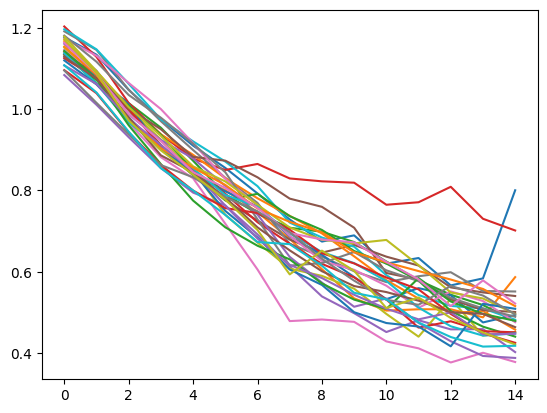

The 95% CI for threshold is 0.1 - 0.86375
The 95% CI for TSS is 0.565301511666119 - 0.8198652645415708

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 32.37 seconds
Max CPU memory used: 9924.48 MB
Max GPU memory used: 435.53 MB


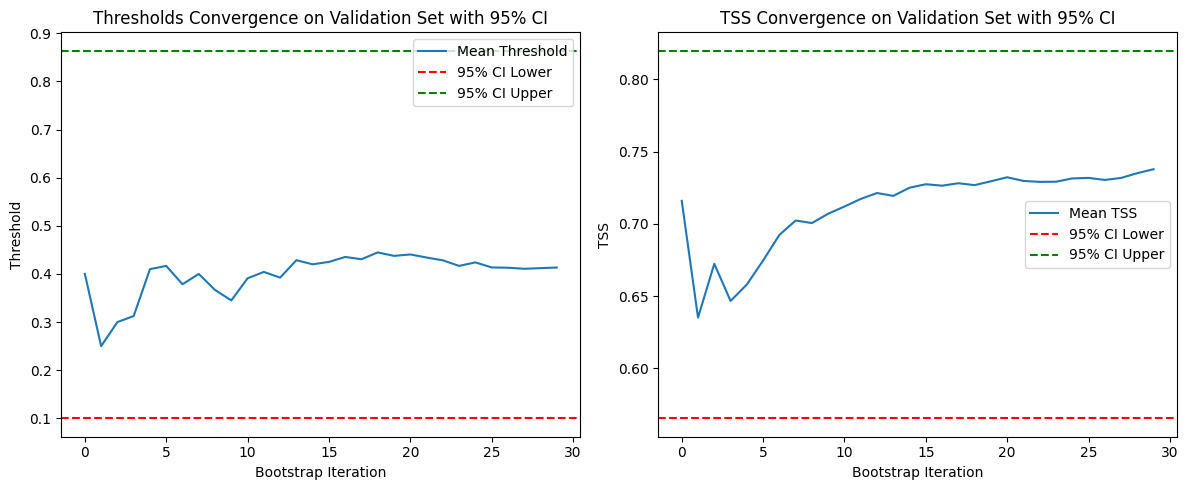

In [87]:
NRT_lead0_Mplus_24_whole = train_lstm()
NRT_lead0_Mplus_24_whole.train(NRT_nowcasting_obj_24.inputs_profile, NRT_nowcasting_obj_24.labels, "Mplus_train", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'),n_epoch=15)

In [91]:
save_dir_nrt = ".\\LSTM_models\\Opr_nrtSHARP"

In [92]:
for i, model in enumerate(NRT_lead0_Mplus_24_whole.models):
    os.makedirs(save_dir_nrt, exist_ok=True)
    model_path = os.path.join(save_dir_nrt, f"NRT_lead0_Mplus_24_whole{i}.pth")
    torch.save(model.state_dict(), model_path)

Bootstrap iteration 1/30
Epoch 1, avg loss: 1.215464174747467
Epoch 2, avg loss: 1.1796510338783264
Epoch 3, avg loss: 1.1177862763404847
Epoch 4, avg loss: 1.048383927345276
Epoch 5, avg loss: 0.9908905625343323
Epoch 6, avg loss: 0.9037765622138977
Epoch 7, avg loss: 0.8792440295219421
Epoch 8, avg loss: 0.8079185009002685
Epoch 9, avg loss: 0.7916408181190491
Epoch 10, avg loss: 0.7177423894405365
Epoch 11, avg loss: 0.6581738501787185
Epoch 12, avg loss: 0.6626685678958892
Epoch 13, avg loss: 0.6165717363357544
Epoch 14, avg loss: 0.607950696349144
Epoch 15, avg loss: 0.5954168379306793
Bootstrap iteration 2/30
Epoch 1, avg loss: 1.178449320793152
Epoch 2, avg loss: 1.147228330373764
Epoch 3, avg loss: 1.098518192768097
Epoch 4, avg loss: 1.0264451801776886
Epoch 5, avg loss: 0.9603986859321594
Epoch 6, avg loss: 0.8965959131717682
Epoch 7, avg loss: 0.8298264861106872
Epoch 8, avg loss: 0.776057904958725
Epoch 9, avg loss: 0.7354451179504394
Epoch 10, avg loss: 0.6827098369598389


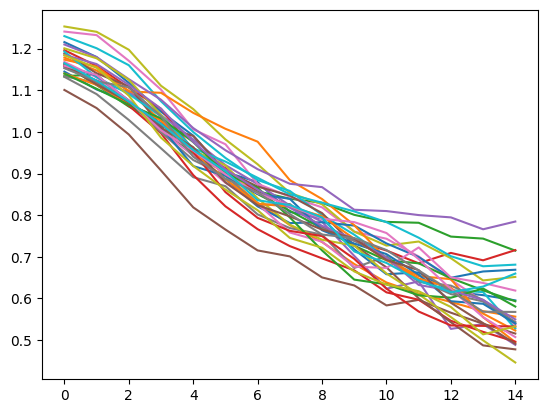

The 95% CI for threshold is 0.2 - 0.9
The 95% CI for TSS is 0.6238721804511279 - 0.8721804511278195

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 22.99 seconds
Max CPU memory used: 10898.39 MB
Max GPU memory used: 437.53 MB


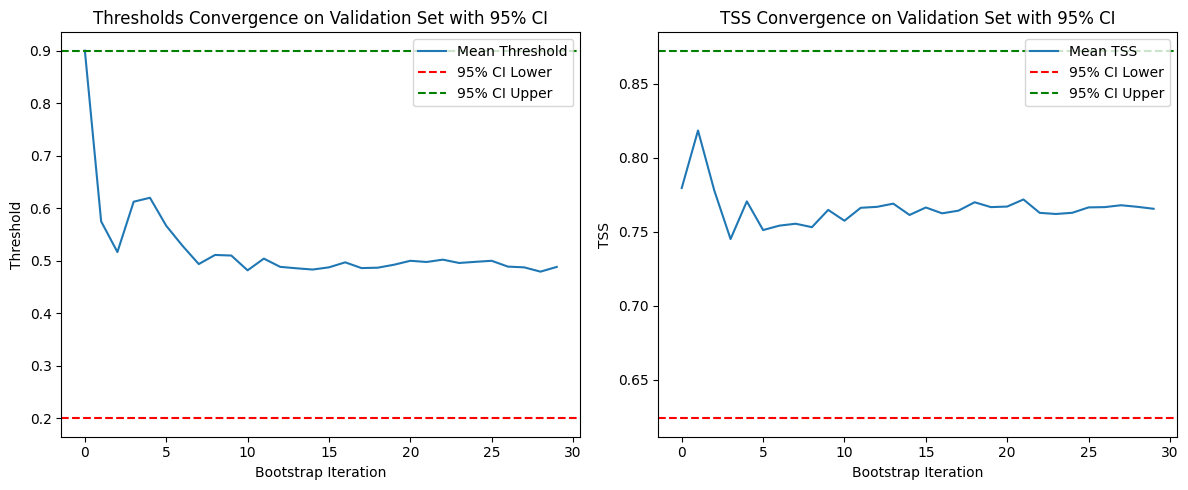

In [93]:
NRT_lead0_Mplus_12_whole = train_lstm()
NRT_lead0_Mplus_12_whole.train(NRT_nowcasting_obj_12.inputs_profile, NRT_nowcasting_obj_12.labels, "Mplus_train", pd.to_datetime('2010-01-01'), pd.to_datetime('2020-01-01'),n_epoch=15)

In [94]:
for i, model in enumerate(NRT_lead0_Mplus_12_whole.models):
    os.makedirs(save_dir_nrt, exist_ok=True)
    model_path = os.path.join(save_dir_nrt, f"NRT_lead0_Mplus_12_whole{i}.pth")
    torch.save(model.state_dict(), model_path)

Bootstrap iteration 1/30
Epoch 1, avg loss: 1.2498399530138289
Epoch 2, avg loss: 1.227573105267116
Epoch 3, avg loss: 1.185833181653704
Epoch 4, avg loss: 1.1500230772154671
Epoch 5, avg loss: 1.1045723131724767
Epoch 6, avg loss: 1.044352310044425
Epoch 7, avg loss: 0.9787257739475795
Epoch 8, avg loss: 0.9299093059131077
Epoch 9, avg loss: 0.880139946937561
Epoch 10, avg loss: 0.8313354849815369
Epoch 11, avg loss: 0.7935834356716701
Epoch 12, avg loss: 0.7597510388919285
Epoch 13, avg loss: 0.7182009475571769
Epoch 14, avg loss: 0.7147729481969561
Epoch 15, avg loss: 0.7113035236086164
Bootstrap iteration 2/30
Epoch 1, avg loss: 1.2386115108217512
Epoch 2, avg loss: 1.2242872544697352
Epoch 3, avg loss: 1.179244978087289
Epoch 4, avg loss: 1.137883254459926
Epoch 5, avg loss: 1.092247656413487
Epoch 6, avg loss: 1.0417766230446952
Epoch 7, avg loss: 0.9844787972314017
Epoch 8, avg loss: 0.9382144638470241
Epoch 9, avg loss: 0.887925752571651
Epoch 10, avg loss: 0.869594395160675
Ep

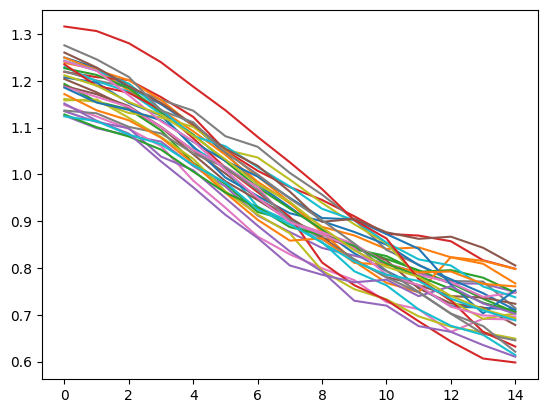

The 95% CI for threshold is 0.2 - 0.6912499999999998
The 95% CI for TSS is 0.5847008547008548 - 0.8569017094017094

[Resource Summary for 30 bootstrapped LSTM models]
Total training time: 15.10 seconds
Max CPU memory used: 10891.95 MB
Max GPU memory used: 443.53 MB


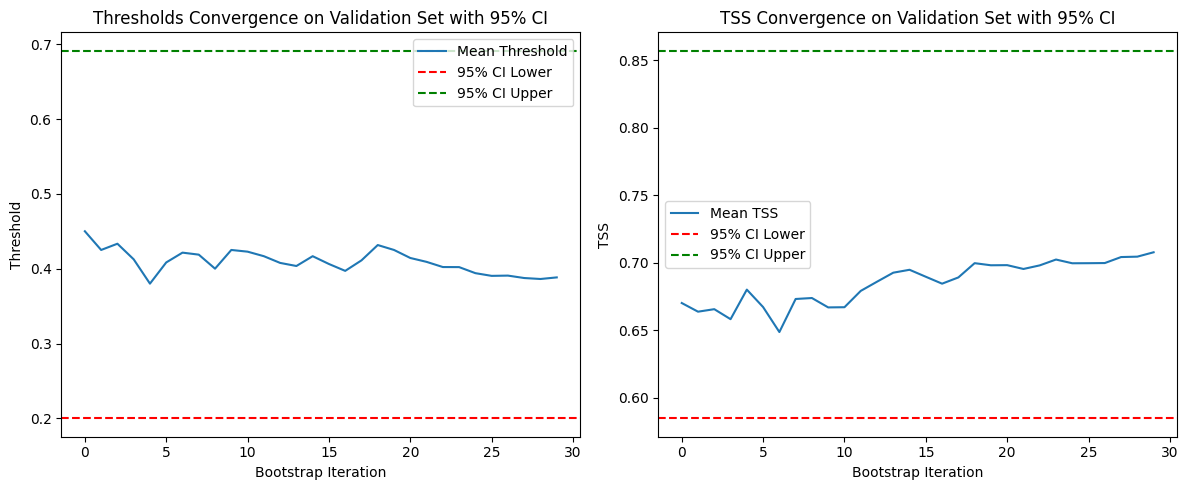

In [95]:
NRT_lead0_Mplus_6_whole = train_lstm()
NRT_lead0_Mplus_6_whole.train(NRT_nowcasting_obj_6.inputs_profile, NRT_nowcasting_obj_6.labels, "Mplus_train", pd.to_datetime('2012-09-14'), pd.to_datetime('2020-01-01'),n_epoch=15)

In [96]:
for i, model in enumerate(NRT_lead0_Mplus_6_whole.models):
    os.makedirs(save_dir_nrt, exist_ok=True)
    model_path = os.path.join(save_dir_nrt, f"NRT_lead0_Mplus_6_whole{i}.pth")
    torch.save(model.state_dict(), model_path)

In [98]:
tsss, hsss, pods, f1s, fars = GenScripts("NRT_lead0_Mplus_24_whole", NRT_lead0_Mplus_24_whole, NRT_nowcasting_obj_24, pd.to_datetime('2020-01-01'), pd.to_datetime('2022-01-01'), save_dir_nrt)

Positive: 73, Negative: 623
TSS: 0.54[0.08,0.81]
HSS: 0.29[0.06,0.47]
POD: 0.80[0.30,1.00]
F1: 0.40[0.19,0.55]
FAR: 0.26[0.14,0.55]


In [99]:
tsss, hsss, pods, f1s, fars = GenScripts("NRT_lead0_Mplus_12_whole", NRT_lead0_Mplus_12_whole, NRT_nowcasting_obj_12, pd.to_datetime('2020-01-01'), pd.to_datetime('2022-01-01'), save_dir_nrt)

Positive: 43, Negative: 483
TSS: 0.58[-0.06,0.82]
HSS: 0.26[-0.03,0.42]
POD: 0.84[0.16,1.00]
F1: 0.36[0.09,0.49]
FAR: 0.26[0.14,0.46]
